In [90]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# Crazy Gaussians

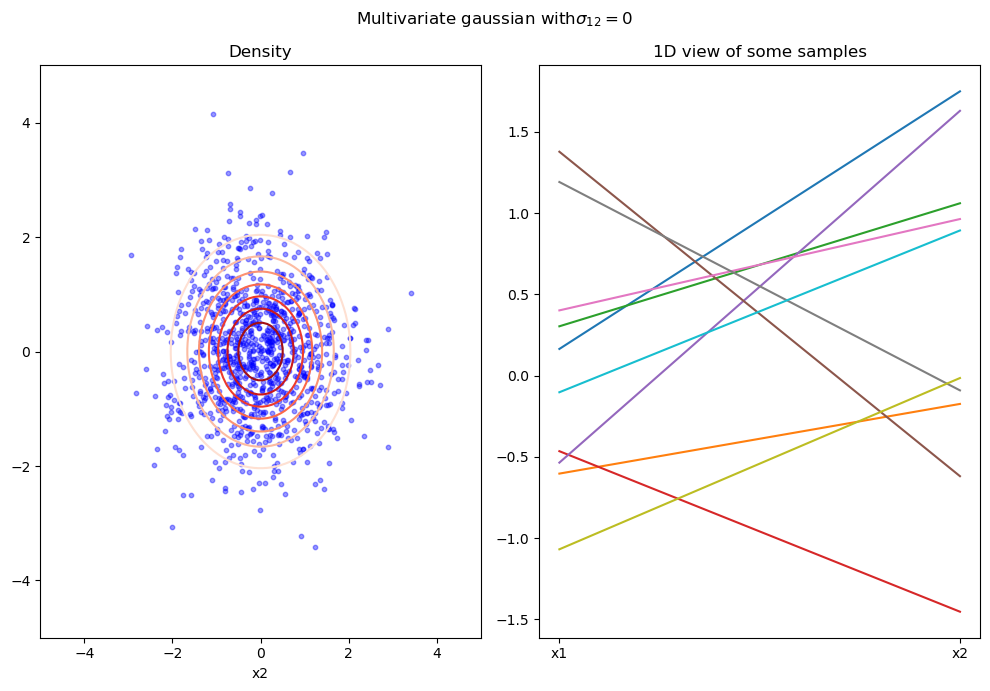

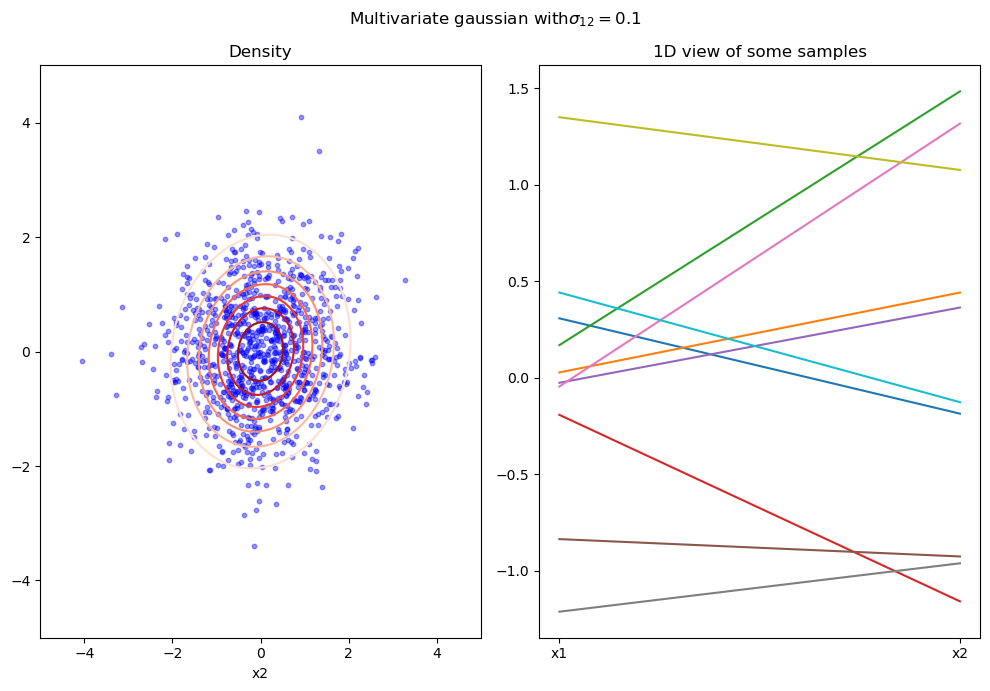

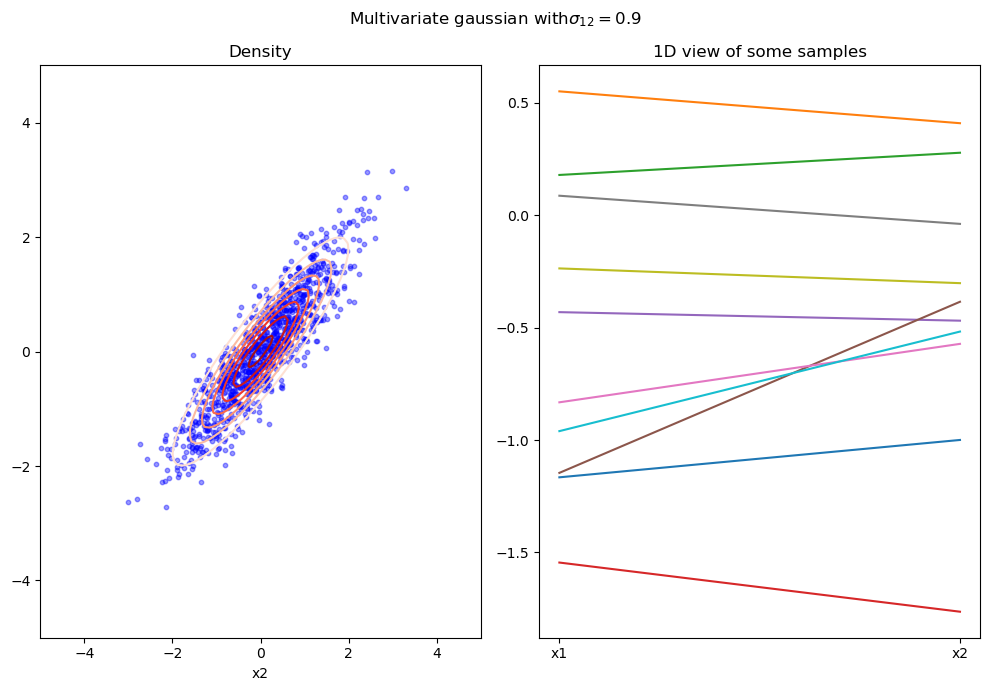

In [73]:
mean = np.zeros(2)
for cov12 in (0, 0.1, 0.9):
    fig, axes = plt.subplots(1,2, figsize=(10,7))
    axes = axes.flatten()
    
    cov = np.array([[1,cov12],
                    [cov12,1]])
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    x_grid, y_grid = np.meshgrid(x, y)
    pos = np.dstack((x_grid, y_grid))
    dens = st.multivariate_normal.pdf(pos,mean, cov)
    samples = np.random.multivariate_normal(mean, cov, 1000)
    axes[0].contour(x_grid, y_grid,dens, cmap="Reds")
    axes[0].scatter(samples[:,0], samples[:,1], alpha = 0.4,s= 10,c="blue")
    for sample in samples[:10]:
        axes[1].plot(sample)
    axes[0].set_title("Density")
    axes[0].set_xlabel("x1")
    axes[0].set_xlabel("x2")
    axes[1].set_title("1D view of some samples")
    axes[1].set_xticks([0,1])
    axes[1].set_xticklabels(["x1","x2"])
    fig.suptitle("Multivariate gaussian with$\\sigma_{12} = " + str(cov12)+"$")
    plt.tight_layout()
    plt.show()
        
    

Higher covariance between dimensions - dimensions are more "aligned" - they tend to increase / discase together.

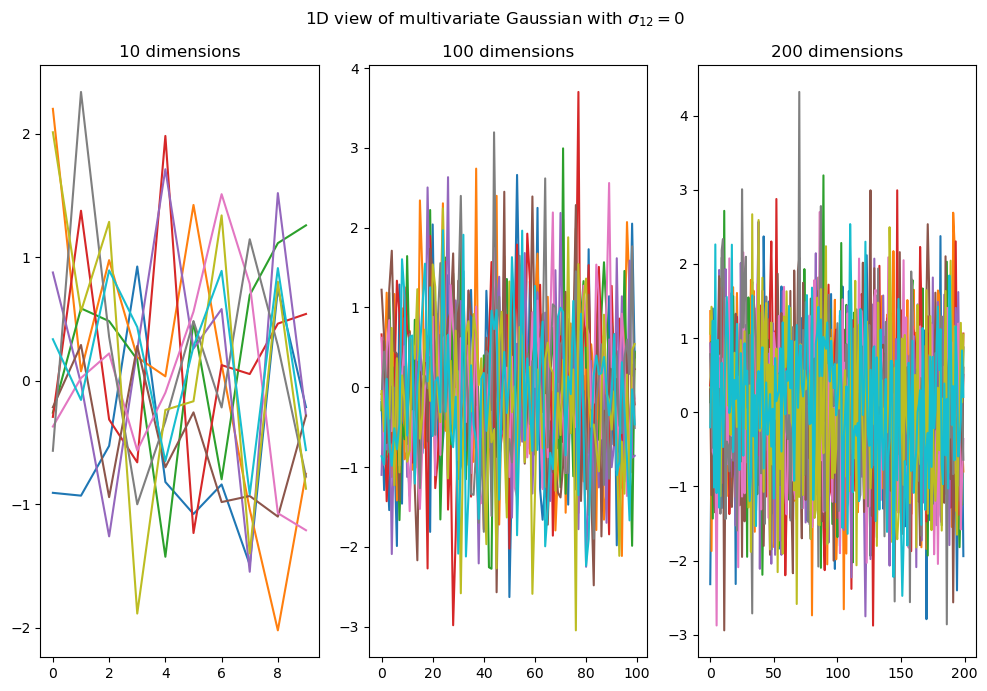

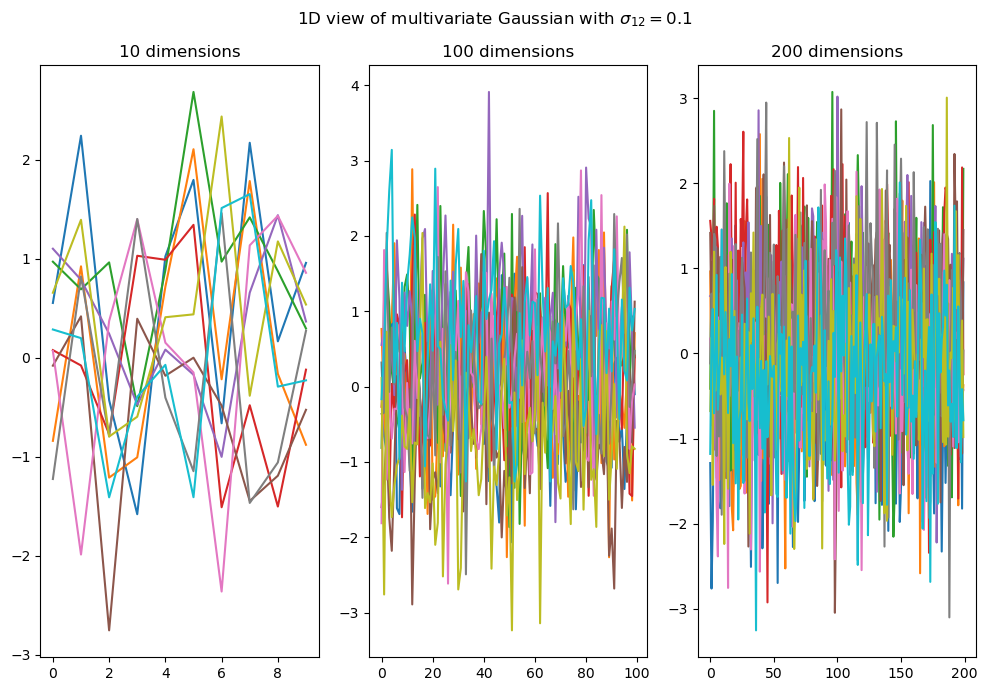

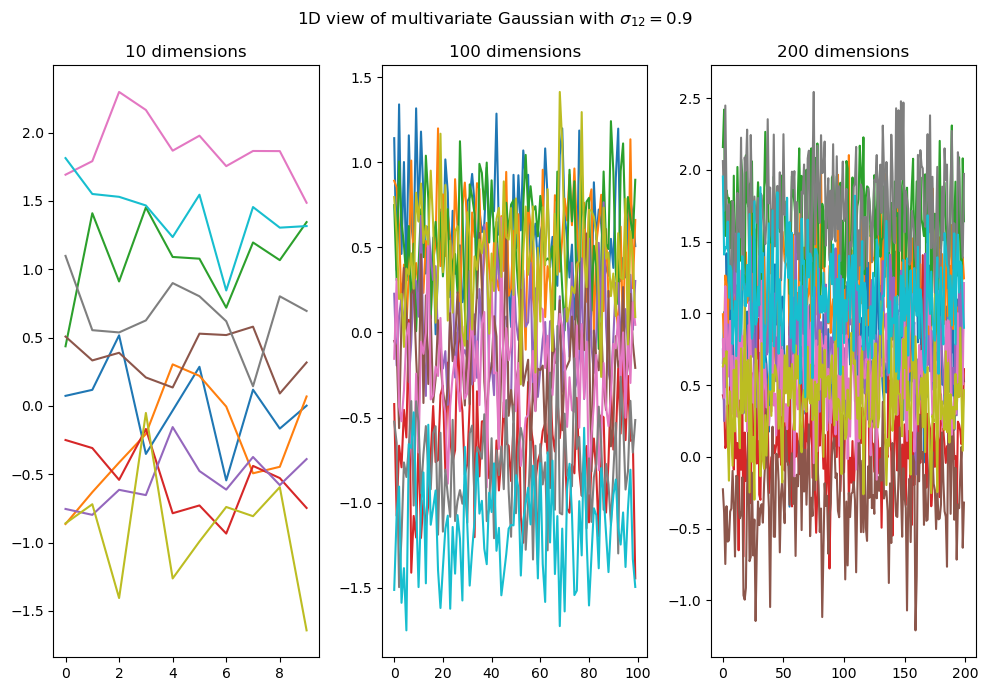

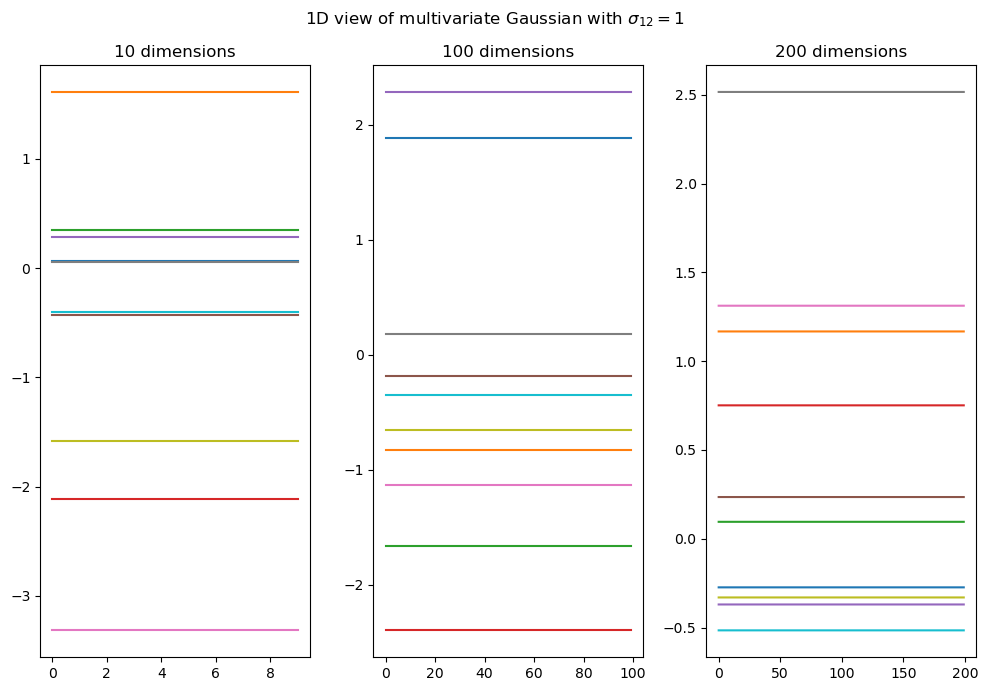

In [89]:
d_to_try = (10, 100, 200)
n_samples = 10
for cross_cov in (0, 0.1, 0.9, 1):
    fig, axes = plt.subplots(1,len(d_to_try), figsize=(10,7))
    axes = axes.flatten()
    for i, d in enumerate(d_to_try):
        mean = np.zeros(d)
        cov = np.ones((d,d)) * cross_cov
        cov = cov * (1-np.eye(d,d)) + np.eye(d,d) # set diagonal to 1
        samples = np.random.multivariate_normal(mean, cov, n_samples)
        for sample in samples:
            axes[i].plot(sample)
            axes[i].set_title(f"{d} dimensions")
    fig.suptitle("1D view of multivariate Gaussian with $\\sigma_{12} = " + str(cross_cov)+"$")
    plt.tight_layout()
    plt.show()

Higher covariance - flatter 1D representations

# Covariance Function (Kernel)

In [164]:
def linear_kernel(X, sigma=1):
    if len(X.shape) == 1:
        X = X.reshape(-1,1)
    G = X @ X.T
    return sigma**2 * G

def rbf_kernel(X, sigma=1, l=1):
    if len(X.shape) == 1:
        X = X.reshape(-1,1)
    D = pairwise_distances(X, metric="euclidean")
    return sigma**2 * np.exp(-1/(2*l**2) * D **2)

def periodic_kernel(X,sigma=1, l=1, p=1):
    if len(X.shape) == 1:
        X = X.reshape(-1,1)
    D = pairwise_distances(X, metric="euclidean")
    return sigma**2 * np.exp(-1/l**2 * np.sin(np.pi * D / p)**2)
    

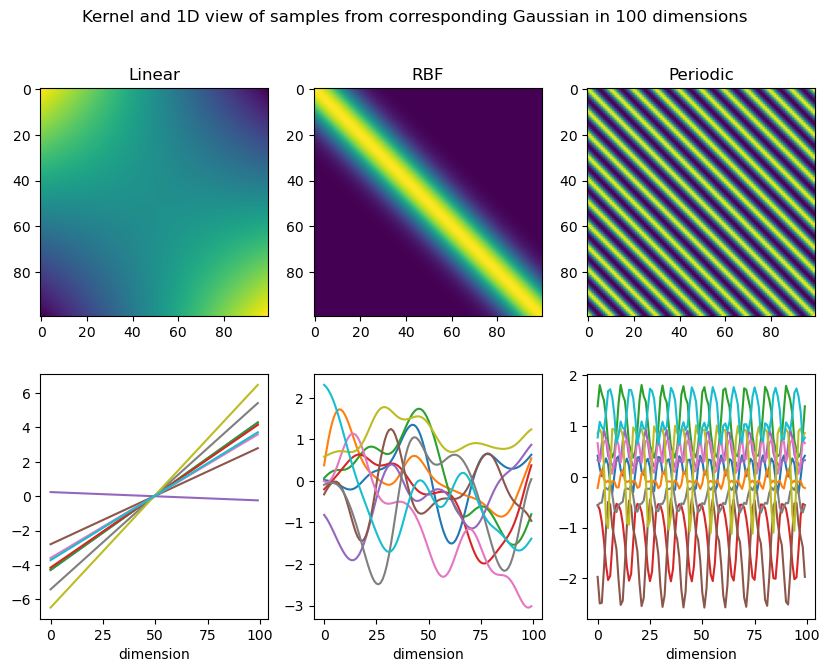

In [173]:
X = np.linspace(-5,5, 100)
# X = np.sort(np.random.uniform(-5,5,100))
d = len(X)
fig, axes = plt.subplots(2,3, figsize=(10,7))
axes = axes.flatten()
kernels = {"Linear": linear_kernel, "RBF": rbf_kernel, "Periodic": periodic_kernel}
for i, (name, kernel) in enumerate( kernels.items()):
    K = kernel(X)
    axes[i].imshow(K)
    axes[i].set_title(name)
    mean = np.zeros(d)
    samples = np.random.multivariate_normal(mean, K, n_samples)
    for sample in samples:
        axes[i+3].plot(sample)
        axes[i+3].set_xlabel("dimension")
        # axes[i+6].plot(X, sample) 
        # axes[i+6].set_xlabel("x")
plt.suptitle(f"Kernel and 1D view of samples from corresponding Gaussian in {d} dimensions")
plt.show()

### TODO: but why is it linear??
### TODO: play with params

# Gaussian Process and Regression

In [ ]:
# TODO: